In [219]:
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [220]:
#Current Season
df_current = pd.read_csv('data/25_26_data.csv')

print("--- 2025-2026 TEAM RANKINGS ---")
print(df_current.head())

--- 2025-2026 TEAM RANKINGS ---
   playerId  season          name team position situation  games_played  \
0   8478043    2025  Sam Lafferty  CHI        C     other            29   
1   8478043    2025  Sam Lafferty  CHI        C       all            29   
2   8478043    2025  Sam Lafferty  CHI        C      5on5            29   
3   8478043    2025  Sam Lafferty  CHI        C      4on5            29   
4   8478043    2025  Sam Lafferty  CHI        C      5on4            29   

   icetime  shifts  gameScore  ...  OffIce_F_xGoals  OffIce_A_xGoals  \
0     85.0     1.0      -0.75  ...             0.44             0.06   
1  14959.0   354.0       0.83  ...            69.00            91.90   
2  14856.0   351.0       0.83  ...            44.53            62.05   
3      0.0     0.0       0.00  ...             0.00             0.00   
4     18.0     2.0      -0.18  ...             0.49             0.22   

   OffIce_F_shotAttempts  OffIce_A_shotAttempts  xGoalsForAfterShifts  \
0          

In [221]:
#Sort by team

df_current['composite_score'] = (df_current['onIce_xGoalsPercentage'] * 100) + df_current['I_F_primaryAssists'] + df_current['I_F_hits']

df_current = df_current[df_current['situation'] == 'all']
team_rankings = df_current.groupby('team')['composite_score'].sum().sort_values(ascending=False)

print(team_rankings)

team
FLA    4018.0
MIN    3861.0
OTT    3798.0
PIT    3710.0
BUF    3644.0
CAR    3612.0
NYR    3594.0
VGK    3575.0
BOS    3555.0
PHI    3552.0
EDM    3548.0
MTL    3516.0
SJS    3471.0
TBL    3461.0
COL    3406.0
ANA    3382.0
NYI    3373.0
CGY    3343.0
LAK    3314.0
CBJ    3304.0
UTA    3271.0
DAL    3271.0
NJD    3216.0
WSH    3184.0
WPG    3071.0
DET    3067.0
TOR    3046.0
VAN    2969.0
STL    2927.0
SEA    2897.0
NSH    2587.0
CHI    2238.0
Name: composite_score, dtype: float64


In [222]:
#Historical Seasons     
df_historical = pd.read_csv('data/08_25_data.csv')

print(df_historical.head())

   playerId  season              name team position situation  games_played  \
0   8462196    2008  Stephane Robidas  DAL        D     other            72   
1   8462196    2008  Stephane Robidas  DAL        D       all            72   
2   8462196    2008  Stephane Robidas  DAL        D      5on5            72   
3   8462196    2008  Stephane Robidas  DAL        D      4on5            72   
4   8462196    2008  Stephane Robidas  DAL        D      5on4            72   

    icetime  shifts  gameScore  ...  OffIce_F_xGoals  OffIce_A_xGoals  \
0    6729.0   105.0      31.93  ...             6.79            12.11   
1  105958.0  2026.0      31.71  ...            95.61           116.39   
2   74053.0  1480.0      31.71  ...            66.29            74.66   
3   10397.0   235.0      30.26  ...             2.24            27.37   
4   14779.0   206.0      31.69  ...            19.15             1.47   

   OffIce_F_shotAttempts  OffIce_A_shotAttempts  xGoalsForAfterShifts  \
0            

In [223]:
#Historical Composites

df_historical['composite_score'] = (df_historical['onIce_xGoalsPercentage'] * 100) + df_historical['I_F_primaryAssists'] + df_historical['I_F_hits']

df_historical = df_historical[df_historical['situation'] == 'all']
historical_team_rankings = df_historical.groupby(['team', 'season'])['composite_score'].sum().sort_values(ascending=False).reset_index()

print("--- HISTORICAL TEAM RANKINGS ---")
print(historical_team_rankings)

--- HISTORICAL TEAM RANKINGS ---
    team  season  composite_score
0    PIT    2010           4493.0
1    TOR    2022           4479.0
2    FLA    2024           4461.0
3    NYI    2014           4427.0
4    CBJ    2013           4378.0
..   ...     ...              ...
517  DAL    2012           2356.0
518  S.J    2012           2355.0
519  CGY    2012           2214.0
520  BUF    2012           2129.0
521  N.J    2020           2104.0

[522 rows x 3 columns]


In [224]:
#Ranking Stanley Cup Winners

champions = {
    2008: 'DET', 2009: 'PIT', 2010: 'CHI', 2011: 'BOS', 2012: 'LAK',
    2013: 'CHI', 2014: 'LAK', 2015: 'CHI', 2016: 'PIT', 2017: 'PIT',
    2018: 'WSH', 2019: 'STL', 2020: 'TBL', 2021: 'TBL', 2022: 'COL',
    2023: 'VGK', 2024: 'FLA', 2025: 'FLA'
}

historical_team_rankings['is_cup_winner'] = historical_team_rankings.apply(lambda row: champions.get(row['season']) == row['team'], axis=1)

cup_winners_ranked = historical_team_rankings[historical_team_rankings['is_cup_winner'] ==True].sort_values(by='composite_score', ascending=False).reset_index(drop=True)

print("--- STANLEY CUP WINNERS COMPOSITE RANKED ---")
print(cup_winners_ranked)

--- STANLEY CUP WINNERS COMPOSITE RANKED ---
   team  season  composite_score  is_cup_winner
0   FLA    2024           4461.0           True
1   PIT    2016           4015.0           True
2   PIT    2009           4009.0           True
3   VGK    2023           3989.0           True
4   BOS    2011           3692.0           True
5   PIT    2017           3508.0           True
6   TBL    2021           3502.0           True
7   COL    2022           3437.0           True
8   WSH    2018           3409.0           True
9   CHI    2010           3396.0           True
10  STL    2019           3247.0           True
11  CHI    2015           3146.0           True
12  DET    2008           3133.0           True
13  CHI    2013           3001.0           True


In [225]:
#Player Composite Scores

player_leaderboard = df_current[['name', 'team', 'composite_score']].sort_values(
    by=['team', 'composite_score'],
    ascending=[True, False]
).reset_index(drop=True)

print("--- PLAYER SCORES ---")
print(player_leaderboard)

--- PLAYER SCORES ---
                    name team  composite_score
0          Ross Johnston  ANA            244.0
1            Radko Gudas  ANA            218.0
2           Jacob Trouba  ANA            201.0
3           Jeffrey Viel  ANA            182.0
4       Beckett Sennecke  ANA            173.0
..                   ...  ...              ...
935          Ilya Protas  WSH             65.0
936         Brett Leason  WSH             64.0
937  Trevor van Riemsdyk  WSH             61.0
938      Declan Chisholm  WSH             56.0
939      Bogdan Trineyev  WSH             55.0

[940 rows x 3 columns]


In [226]:
#Historical Composite Scores --- START OF ML

df_scores = df_historical[['name', 'season', 'composite_score']].copy()

In [227]:
#Lag Creation

df_scores['season'] = df_scores['season'] - 1

In [228]:
#Merge to historical data

df_lagged = pd.merge(
    df_historical,
    df_scores,
    on=['name', 'season'],
    suffixes=('', '_next_year')
)

In [229]:
#Linear Regression Composite Score Predictor

features = ['onIce_xGoalsPercentage', 'I_F_primaryAssists', 'I_F_hits', 'composite_score']

X = df_lagged[features]
y = df_lagged['composite_score_next_year']


X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.2, random_state = 42)

In [230]:
#Model Start

model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [231]:
#Model Accuracy

model_accuracy = model.score(X_test, y_test)
print(f"R^2 Accuracy Score: {model_accuracy: .2f}")

R^2 Accuracy Score:  0.47


In [232]:
#Predict Current Season

df_current['predicted_next_year_score'] = model.predict(df_current[features])

In [233]:
#Future Predictions

future_predictions = df_current.groupby('team')['predicted_next_year_score'].sum().sort_values(ascending=False).reset_index()

In [234]:
#Predictions

future_projections = df_current.groupby('team')['predicted_next_year_score'].sum().sort_values(ascending=False).reset_index()

print("\n--- PREDICTED TEAM STANDINGS ---")
print(future_predictions)


--- PREDICTED TEAM STANDINGS ---
   team  predicted_next_year_score
0   FLA                4155.304285
1   PIT                4041.164070
2   MIN                3869.810615
3   OTT                3798.991413
4   PHI                3745.765104
5   BUF                3710.600170
6   CAR                3700.025841
7   CGY                3692.799662
8   NYR                3662.309594
9   BOS                3618.369360
10  EDM                3609.541615
11  VGK                3591.895164
12  TBL                3587.105807
13  MTL                3546.950331
14  NJD                3511.814040
15  COL                3503.236541
16  NYI                3460.794649
17  SJS                3445.538150
18  CBJ                3404.702212
19  ANA                3374.991882
20  LAK                3308.557070
21  DAL                3293.681936
22  UTA                3261.487043
23  WSH                3249.236330
24  WPG                3249.231928
25  TOR                3230.516388
26  VAN              

In [235]:
#Visualization

current_teams = df_current.groupby('team')['composite_score'].sum().reset_index()
future_teams = df_current.groupby('team')['predicted_next_year_score'].sum().reset_index()

viz_df = pd.merge(current_teams, future_teams, on='team')

#Sorting by predicted future score
viz_df = viz_df.sort_values(by='predicted_next_year_score', ascending=False)

In [236]:
#Reshape data for Seaborn (Melting)

melted_df = pd.melt(viz_df, id_vars='team', value_vars=['composite_score', 'predicted_next_year_score'],
                var_name='Season Type', value_name= 'Total Score'
                )

<Axes: xlabel='team', ylabel='Total Score'>

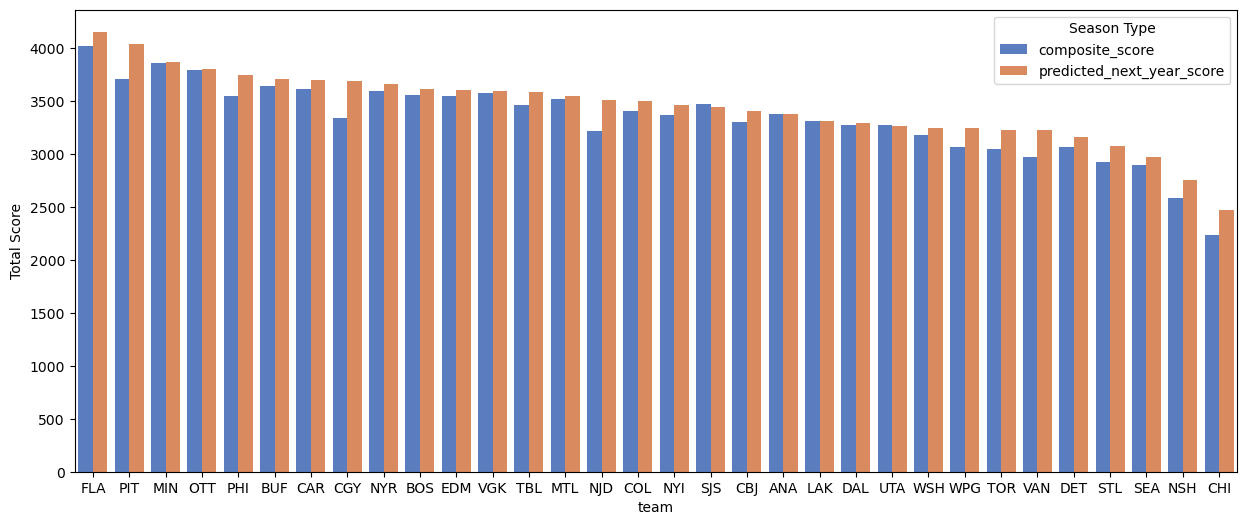

In [ ]:
#Plot

plt.figure(figsize=(15, 6))
sns.barplot(data=melted_df, x='team', y='Total Score', hue='Season Type', palette = 'muted')

#Styling

plt.title('NHL Team Analysis: Current Composite Score vs. AI Future Projection', fontsize=16, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Total Score', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

#The Plot
plt.show()

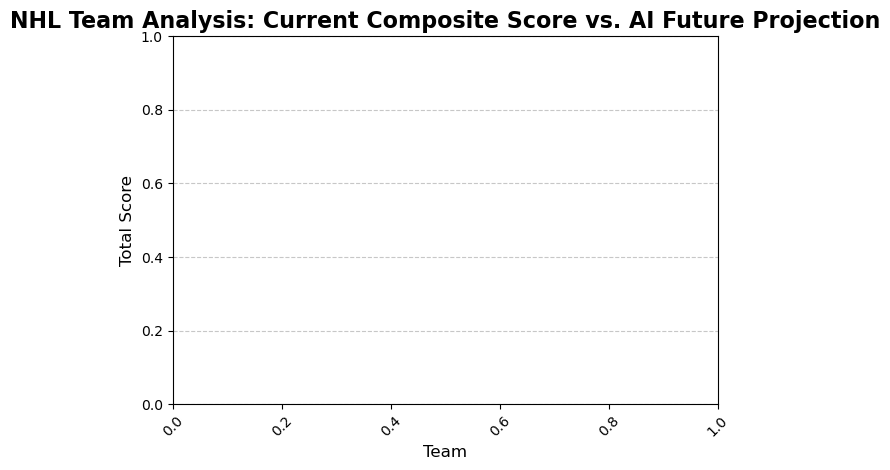

In [238]:
#Styling

plt.title('NHL Team Analysis: Current Composite Score vs. AI Future Projection', fontsize=16, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Total Score', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

#The Plot
plt.show()
